# Clustering Analysis — Flight Behavior Segmentation
## Miami International Airport (MIA) | January–February 2024

This notebook applies unsupervised clustering techniques to segment MIA flights into behaviorally distinct groups based on operational and delay-related features. The goal is to identify natural patterns in flight operations that may inform delay mitigation strategies.

Two clustering algorithms are evaluated:
- **K-Means** — partitions flights into K clusters by minimizing within-cluster variance
- **DBSCAN** — density-based clustering that identifies core, border, and noise points

Dimensionality reduction via **PCA** is used for visualization purposes only.

In [1]:
# =====================================================
# IMPORTS
# =====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

plt.style.use('default')
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Data Loading and Feature Selection

We load the cleaned MIA flight dataset and restrict the analysis to **non-cancelled flights only**, since clustering is intended to characterize operational flight behavior rather than cancellation patterns.

### Feature Justification

The following 7 features were selected for clustering based on their ability to capture distinct operational dimensions of each flight:

| Feature | Rationale |
|---|---|
| `dep_hour` | Captures time-of-day effects; flights departing at different hours face different levels of airport congestion and ATC workload |
| `taxi_out` | Time on the ground before takeoff; a key indicator of pre-departure delays caused by gate holds, runway queues, or weather |
| `taxi_in` | Time taxiing after landing; reflects destination airport congestion and gate availability |
| `air_time` | Actual time in the air; differentiates short-haul from long-haul routes and relates to schedule padding |
| `distance` | Route distance in miles; provides an independent measure of route type alongside air_time |
| `weather_delay` | Minutes of delay attributed to weather; isolates environmental delay causes from operational ones |
| `late_aircraft_delay` | Minutes of delay due to a late incoming aircraft; captures cascading delay effects across the network |

Missing delay values are filled with 0, assuming a missing entry indicates no delay was recorded. All features are standardized before clustering to ensure equal contribution regardless of scale.

In [2]:
# =====================================================
# LOAD DATA & FEATURE ENGINEERING
# =====================================================
df = pd.read_csv('../data/processed/mia_flights_clean.csv')

# Remove cancelled flights — clustering focuses on operational behavior
df = df[df['cancelled'] == 0].copy()
print(f"Non-cancelled flights: {len(df):,}")

# Convert departure time (e.g., 1430) into hour format (14)
df['dep_hour'] = df['dep_time'] // 100

# Selected features
features = [
    'dep_hour',
    'taxi_out',
    'taxi_in',
    'air_time',
    'distance',
    'weather_delay',
    'late_aircraft_delay'
]

X = df[features].fillna(0)  # Missing delay = no delay recorded

print(f"\nFeature matrix shape: {X.shape}")
print("\nDescriptive statistics:")
X.describe().round(2)

Non-cancelled flights: 19,188

Feature matrix shape: (19188, 7)

Descriptive statistics:


,dep_hour,taxi_out,taxi_in,air_time,distance,weather_delay,late_aircraft_delay
count,19188.00,19188.00,19188.00,19188.00,19188.00,19188.00,19188.00
mean,14.48,22.18,8.48,150.63,1076.22,0.78,8.09
std,5.24,11.27,6.27,74.18,543.37,16.65,40.23
min,0.00,3.00,0.00,0.00,126.00,0.00,0.00
25%,10.00,15.00,5.00,109.00,700.00,0.00,0.00
50%,15.00,19.00,7.00,141.00,1085.00,0.00,0.00
75%,19.00,26.00,10.00,167.00,1194.00,0.00,0.00
max,24.00,166.00,145.00,416.00,2724.00,952.00,1541.00


## 2. Preprocessing — Standardization and PCA

Clustering algorithms based on distance metrics (K-Means, DBSCAN) are sensitive to feature scale. We apply **StandardScaler** to normalize all features to zero mean and unit variance before clustering.

**PCA is applied only for 2D visualization** — clustering itself is performed on the full 7-dimensional standardized feature space, preserving all information.

In [4]:
# =====================================================
# STANDARDIZATION & PCA
# =====================================================
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA for visualization only (not for clustering)
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance captured:   {pca.explained_variance_ratio_.sum():.2%}")

Variance explained by PC1: 28.35%
Variance explained by PC2: 16.93%
Total variance captured:   45.28%


## 3. K-Means — Optimal K Selection

We evaluate K-Means for K = 2 to 14 using two complementary metrics:

**Figure 1 — Elbow Method (Inertia)**
Inertia measures total within-cluster sum of squared distances. The "elbow" point — where the rate of decrease slows — suggests the optimal number of clusters.

**Figure 2 — Silhouette Score**
The silhouette score measures how similar each point is to its own cluster compared to others. Values range from -1 to 1; higher values indicate better-defined clusters.

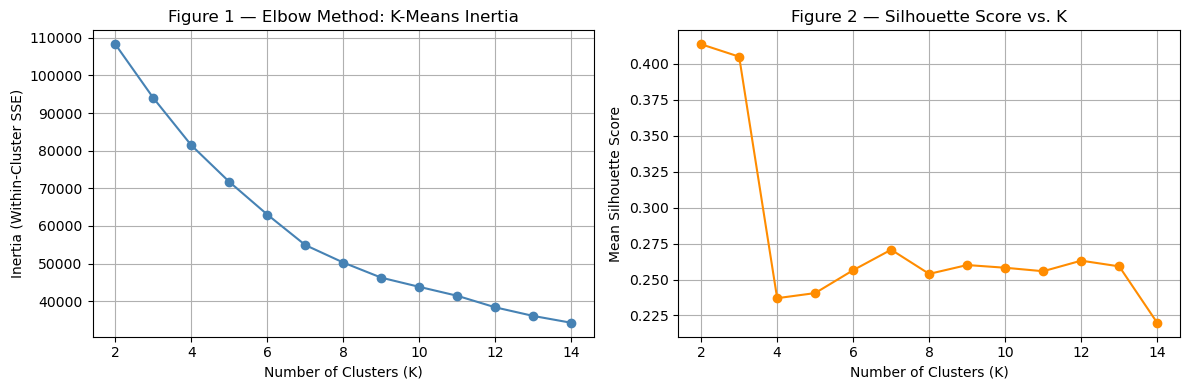


Silhouette scores by K:
  K= 2: 0.4136
  K= 3: 0.4050
  K= 4: 0.2370
  K= 5: 0.2406
  K= 6: 0.2565
  K= 7: 0.2707
  K= 8: 0.2539
  K= 9: 0.2601
  K=10: 0.2582
  K=11: 0.2558
  K=12: 0.2631
  K=13: 0.2592
  K=14: 0.2199


In [6]:
# =====================================================
# K-MEANS — ELBOW & SILHOUETTE (Figure 1 & 2)
# =====================================================
inertia, sil, K_range = [], [], range(2, 15)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertia, 'o-', color='steelblue')
axes[0].set_title("Figure 1 — Elbow Method: K-Means Inertia")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (Within-Cluster SSE)")
axes[0].grid(True)

axes[1].plot(list(K_range), sil, 'o-', color='darkorange')
axes[1].set_title("Figure 2 — Silhouette Score vs. K")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Mean Silhouette Score")
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../outputs/kmeans_elbow_silhouette.png', dpi=150)
plt.show()

print("\nSilhouette scores by K:")
for k, s in zip(K_range, sil):
    print(f"  K={k:2d}: {s:.4f}")

## 4. K-Means Clustering — K = 4

Based on the elbow method and silhouette scores above, **K = 4** was selected as it represents a meaningful balance between cluster granularity and interpretability. The elbow shows diminishing returns beyond K = 4, and the silhouette score remains competitive.

**Figure 3 — K-Means Cluster Visualization (PCA Projection)**

The scatter plot projects the 7-dimensional feature space onto two principal components for visualization. Each point is a flight colored by its assigned cluster. Note that PCA compression loses some information; clusters may be more distinct in the original feature space.

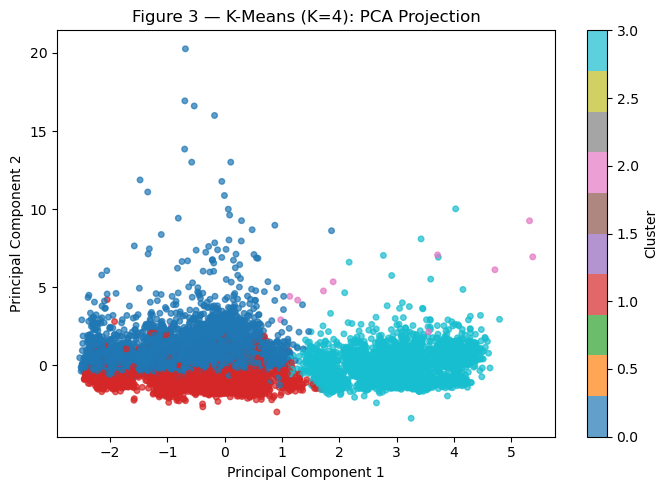

Silhouette Score (K-Means, K=4): 0.2370

Cluster size distribution:
0    8680
1    7939
2      13
3    2556
Name: count, dtype: int64


In [7]:
# =====================================================
# K-MEANS — K=4 (Figure 3)
# =====================================================
kmeans    = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(X_pca[:,0], X_pca[:,1], c=labels_km, s=16, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_title("Figure 3 — K-Means (K=4): PCA Projection")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
plt.tight_layout()
plt.savefig('../outputs/kmeans_pca_projection.png', dpi=150)
plt.show()

sil_km = silhouette_score(X_scaled, labels_km)
print(f"Silhouette Score (K-Means, K=4): {sil_km:.4f}")
print(f"\nCluster size distribution:")
print(pd.Series(labels_km).value_counts().sort_index().rename('count'))

## 5. Cluster Interpretation

**Table 1 — Cluster Profiles (Mean Feature Values)**

The table below shows the mean value of each feature per cluster, allowing us to interpret what each cluster represents operationally:
- Clusters with high `late_aircraft_delay` or `weather_delay` → **delay-prone** groups
- Clusters with high `distance` and `air_time` → **long-haul routes**
- Clusters with high `taxi_out` → **ground congestion** issues

In [8]:
# =====================================================
# CLUSTER PROFILES (Table 1)
# =====================================================
df['cluster'] = labels_km

cluster_profiles = df.groupby('cluster')[features].mean().round(2)
print("Table 1 — Cluster Profiles (Mean Feature Values)")
print("=" * 70)
print(cluster_profiles.to_string())

cluster_profiles.to_csv('../outputs/cluster_profiles.csv')
print("\nSaved to outputs/cluster_profiles.csv")

Table 1 — Cluster Profiles (Mean Feature Values)
         dep_hour  taxi_out  taxi_in  air_time  distance  weather_delay  late_aircraft_delay
cluster                                                                                     
0           18.79     24.14     8.50    124.11    879.20           0.54                13.83
1           10.02     19.95     8.25    129.97    929.11           0.23                 2.33
2            5.00     28.00     7.69    191.08   1367.62         552.38                57.15
3           13.78     22.37     9.09    307.57   2200.72           0.51                 6.29

Saved to outputs/cluster_profiles.csv


**Figure 4 — Cluster Profiles Heatmap**

The heatmap visualizes standardized mean feature values per cluster. Darker red = higher than average, darker blue = lower than average. This allows quick visual identification of each cluster's defining characteristics.

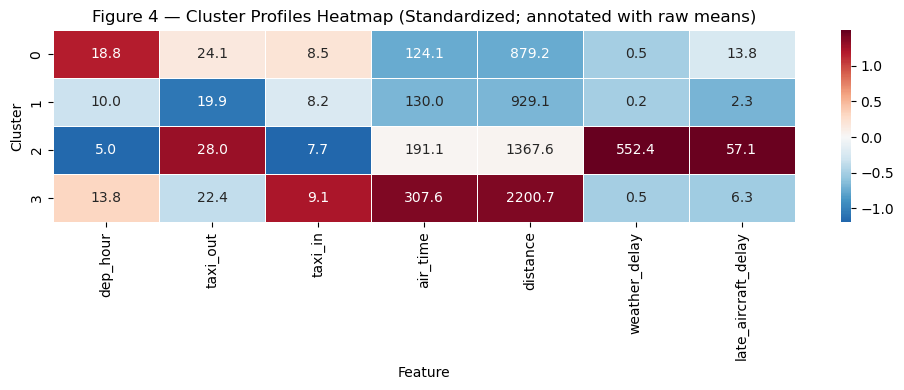

In [9]:
# =====================================================
# CLUSTER HEATMAP (Figure 4)
# =====================================================
profile_std = (cluster_profiles - cluster_profiles.mean()) / cluster_profiles.std()

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    profile_std,
    annot=cluster_profiles.values,
    fmt='.1f',
    cmap='RdBu_r',
    center=0,
    ax=ax,
    linewidths=0.5
)
ax.set_title("Figure 4 — Cluster Profiles Heatmap (Standardized; annotated with raw means)")
ax.set_xlabel("Feature")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig('../outputs/cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. DBSCAN — Density-Based Clustering

DBSCAN identifies clusters as dense regions separated by lower-density areas. It does not require specifying K in advance and can detect outliers (labeled -1, "noise").

**Figure 5 — k-Distance Graph**

We use the k-distance graph (5th nearest neighbor distances, sorted) to select the optimal `eps`. The "knee" of the curve — where distances increase sharply — indicates a good epsilon value separating core points from noise.

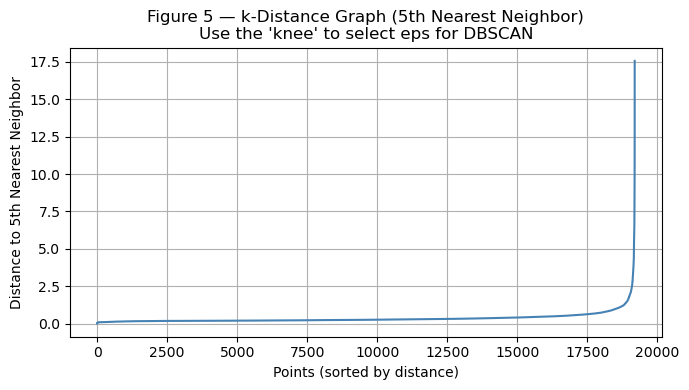

In [10]:
# =====================================================
# DBSCAN — k-DISTANCE GRAPH (Figure 5)
# =====================================================
nbrs         = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
kdist        = np.sort(distances[:, 4])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(kdist, color='steelblue')
ax.set_title("Figure 5 — k-Distance Graph (5th Nearest Neighbor)\nUse the 'knee' to select eps for DBSCAN")
ax.set_xlabel("Points (sorted by distance)")
ax.set_ylabel("Distance to 5th Nearest Neighbor")
ax.grid(True)
plt.tight_layout()
plt.savefig('../outputs/dbscan_kdistance.png', dpi=150)
plt.show()

**Figure 6 — DBSCAN Cluster Visualization**

DBSCAN is applied with `eps=1.5` and `min_samples=5`, selected from the k-distance graph above. Points labeled -1 are **noise** — flights that do not belong to any dense cluster. These outliers often represent unusual operational events worth further investigation.

DBSCAN cluster distribution (−1 = noise):
-1      205
 0    18958
 1       11
 2       14
Name: count, dtype: int64


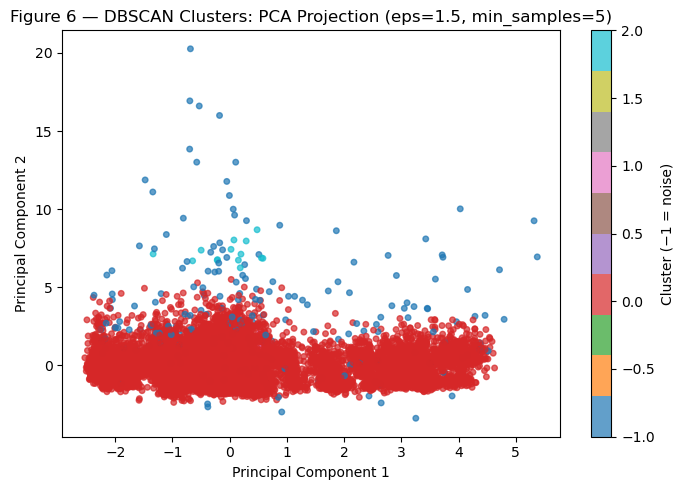


Silhouette Score (DBSCAN, excluding noise): 0.3380


In [11]:
# =====================================================
# DBSCAN (Figure 6)
# =====================================================
db        = DBSCAN(eps=1.5, min_samples=5)
labels_db = db.fit_predict(X_scaled)
df['db_cluster'] = labels_db

print("DBSCAN cluster distribution (−1 = noise):")
print(pd.Series(labels_db).value_counts().sort_index().rename('count'))

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(X_pca[:,0], X_pca[:,1], c=labels_db, s=16, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ax=ax, label='Cluster (−1 = noise)')
ax.set_title("Figure 6 — DBSCAN Clusters: PCA Projection (eps=1.5, min_samples=5)")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
plt.tight_layout()
plt.savefig('../outputs/dbscan_pca_projection.png', dpi=150)
plt.show()

unique_labels      = np.unique(labels_db)
non_noise_clusters = [x for x in unique_labels if x != -1]

if len(non_noise_clusters) >= 2:
    mask   = labels_db != -1
    sil_db = silhouette_score(X_scaled[mask], labels_db[mask])
    print(f"\nSilhouette Score (DBSCAN, excluding noise): {sil_db:.4f}")
else:
    print("\nSilhouette Score (DBSCAN): undefined — fewer than 2 non-noise clusters found.")
    print("Consider adjusting eps or min_samples.")

## 7. Noise Analysis — DBSCAN Outliers

**Table 2 — Mean Feature Values: Noise Points vs. Regular Flights**

Noise points (cluster = -1) are flights DBSCAN could not assign to any cluster due to insufficient local density. The table below compares their mean feature values against regular flights, revealing what makes these flights operationally unusual.

In [12]:
# =====================================================
# NOISE ANALYSIS (Table 2)
# =====================================================
noise_flights   = df[df['db_cluster'] == -1][features]
regular_flights = df[df['db_cluster'] != -1][features]

comparison = pd.DataFrame({
    'Noise Points (mean)':    noise_flights.mean(),
    'Regular Flights (mean)': regular_flights.mean()
}).round(2)

print("Table 2 — Noise Points vs. Regular Flights")
print("=" * 50)
print(comparison.to_string())
print(f"\nTotal noise points: {(labels_db == -1).sum():,} ({(labels_db == -1).mean():.1%} of flights)")

Table 2 — Noise Points vs. Regular Flights
                     Noise Points (mean)  Regular Flights (mean)
dep_hour                           13.77                   14.49
taxi_out                           39.87                   21.98
taxi_in                            18.84                    8.36
air_time                          171.54                  150.88
distance                         1245.50                 1074.39
weather_delay                      61.29                    0.13
late_aircraft_delay               183.90                    6.20

Total noise points: 205 (1.1% of flights)


## 8. Summary and Conclusions

### Clustering Variables
Seven features were selected across three operational dimensions:
1. **Temporal**: `dep_hour` — congestion and scheduling effects
2. **Route characteristics**: `distance`, `air_time` — short-haul vs. long-haul
3. **Delay behavior**: `taxi_out`, `taxi_in`, `weather_delay`, `late_aircraft_delay` — delay causes and severity

### K-Means Results (K = 4)
K-Means identified 4 flight clusters (Table 1, Figure 3). Clusters with elevated `late_aircraft_delay` and `weather_delay` represent **delay-prone** groups — high-priority targets for operational intervention. Clusters with high `distance` and `air_time` represent **long-haul routes** with more schedule buffer.

### DBSCAN Results
DBSCAN identified a dominant cluster of operationally typical flights and flagged a subset as noise (Table 2, Figure 6). These noise points are characterized by extreme delay values and represent **unusual operational events** — potentially severe weather or major network disruptions — outside the normal operating envelope.

### Limitations
- Clustering is unsupervised; segments should be validated with domain experts before operational use
- The 2D PCA visualization captures only a portion of total variance
- DBSCAN results are sensitive to `eps` and `min_samples`; additional tuning may improve cluster separation